# CV Assignment 2 - Noise Removal Tool

**Application used:** OCR / Document Scanning

This notebook demonstrates noise removal on the local `noise.webp` image using OpenCV filters. It compares the original and filtered images side by side and saves the processed output for inspection.

In [3]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['image.cmap'] = 'gray'

In [4]:
# -----------------------------
# Sample image input
# -----------------------------
input_image_path = Path('noise.webp')
output_dir = Path('processed_outputs')
output_dir.mkdir(exist_ok=True)

if not input_image_path.exists():
    raise FileNotFoundError(f'Could not find {input_image_path.resolve()}')

image = cv2.imread(str(input_image_path), cv2.IMREAD_GRAYSCALE)
if image is None:
    raise ValueError('Failed to load the sample image.')

## Filter Parameters

This cell stores the selected filter name and kernel size, along with the extra tuning values used by bilateral, Canny, and frequency-domain filters.

In [5]:
# -----------------------------
# User selections
# Change these values and rerun the cell.
# -----------------------------
filter_type = 'median'  # mean, gaussian, box, median, bilateral, adaptive_median, lpf, hpf, band_pass, band_reject, sobel, prewitt, roberts, canny
kernel_size = 5  # 3, 5, or 7

# Optional parameters used by a few filters
bilateral_d = 9
bilateral_sigma_color = 75
bilateral_sigma_space = 75
canny_threshold1 = 100
canny_threshold2 = 200
band_pass_inner = 15
band_pass_outer = 50
band_reject_inner = 15
band_reject_outer = 50

## Filter Functions

This cell defines the actual filtering operations. It includes linear filters, non-linear filters, frequency-domain filters, edge detectors, and a dispatcher that chooses the requested method.

In [6]:
def ensure_odd_valid_kernel(size):
    if size not in (3, 5, 7):
        raise ValueError('kernel_size must be one of 3, 5, or 7')
    return int(size)

def mean_filter(img, size):
    return cv2.blur(img, (size, size))

def gaussian_filter(img, size):
    return cv2.GaussianBlur(img, (size, size), 0)

def box_filter(img, size):
    return cv2.boxFilter(img, -1, (size, size), normalize=True)

def median_filter(img, size):
    return cv2.medianBlur(img, size)

def bilateral_filter(img):
    return cv2.bilateralFilter(img, bilateral_d, bilateral_sigma_color, bilateral_sigma_space)

def adaptive_median_filter(img, size):
    pad = size // 2
    padded = np.pad(img, pad_width=pad, mode='reflect')
    result = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            window = padded[i:i + size, j:j + size]
            zmin = window.min()
            zmax = window.max()
            zmed = np.median(window)
            zxy = img[i, j]
            if zmin < zmed < zmax:
                if zmin < zxy < zmax:
                    result[i, j] = zxy
                else:
                    result[i, j] = zmed
            else:
                result[i, j] = zmed
    return result.astype(np.uint8)

def low_pass_filter(img, size):
    dft = np.fft.fftshift(np.fft.fft2(img))
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.uint8)
    mask[crow - size:crow + size, ccol - size:ccol + size] = 1
    filtered = dft * mask
    inv = np.fft.ifft2(np.fft.ifftshift(filtered))
    return np.clip(np.abs(inv), 0, 255).astype(np.uint8)

def high_pass_filter(img, size):
    dft = np.fft.fftshift(np.fft.fft2(img))
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.ones((rows, cols), np.uint8)
    mask[crow - size:crow + size, ccol - size:ccol + size] = 0
    filtered = dft * mask
    inv = np.fft.ifft2(np.fft.ifftshift(filtered))
    return np.clip(np.abs(inv), 0, 255).astype(np.uint8)

def band_pass_filter(img, inner, outer):
    dft = np.fft.fftshift(np.fft.fft2(img))
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2
    yy, xx = np.ogrid[:rows, :cols]
    dist = np.sqrt((yy - crow) ** 2 + (xx - ccol) ** 2)
    mask = np.logical_and(dist >= inner, dist <= outer).astype(np.uint8)
    filtered = dft * mask
    inv = np.fft.ifft2(np.fft.ifftshift(filtered))
    return np.clip(np.abs(inv), 0, 255).astype(np.uint8)

def band_reject_filter(img, inner, outer):
    dft = np.fft.fftshift(np.fft.fft2(img))
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2
    yy, xx = np.ogrid[:rows, :cols]
    dist = np.sqrt((yy - crow) ** 2 + (xx - ccol) ** 2)
    mask = np.logical_or(dist < inner, dist > outer).astype(np.uint8)
    filtered = dft * mask
    inv = np.fft.ifft2(np.fft.ifftshift(filtered))
    return np.clip(np.abs(inv), 0, 255).astype(np.uint8)

def sobel_filter(img):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    mag = cv2.magnitude(gx, gy)
    return np.clip(mag, 0, 255).astype(np.uint8)

def prewitt_filter(img):
    kx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float32)
    ky = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)
    gx = cv2.filter2D(img, cv2.CV_32F, kx)
    gy = cv2.filter2D(img, cv2.CV_32F, ky)
    mag = cv2.magnitude(gx, gy)
    return np.clip(mag, 0, 255).astype(np.uint8)

def roberts_filter(img):
    kx = np.array([[1, 0], [0, -1]], dtype=np.float32)
    ky = np.array([[0, 1], [-1, 0]], dtype=np.float32)
    gx = cv2.filter2D(img, cv2.CV_32F, kx)
    gy = cv2.filter2D(img, cv2.CV_32F, ky)
    mag = cv2.magnitude(gx, gy)
    return np.clip(mag, 0, 255).astype(np.uint8)

def canny_filter(img):
    return cv2.Canny(img, canny_threshold1, canny_threshold2)

def apply_selected_filter(img, selected_filter, size):
    size = ensure_odd_valid_kernel(size)
    if selected_filter == 'mean':
        return mean_filter(img, size)
    if selected_filter == 'gaussian':
        return gaussian_filter(img, size)
    if selected_filter == 'box':
        return box_filter(img, size)
    if selected_filter == 'median':
        return median_filter(img, size)
    if selected_filter == 'bilateral':
        return bilateral_filter(img)
    if selected_filter == 'adaptive_median':
        return adaptive_median_filter(img, size)
    if selected_filter == 'lpf':
        return low_pass_filter(img, size)
    if selected_filter == 'hpf':
        return high_pass_filter(img, size)
    if selected_filter == 'band_pass':
        return band_pass_filter(img, band_pass_inner, band_pass_outer)
    if selected_filter == 'band_reject':
        return band_reject_filter(img, band_reject_inner, band_reject_outer)
    if selected_filter == 'sobel':
        return sobel_filter(img)
    if selected_filter == 'prewitt':
        return prewitt_filter(img)
    if selected_filter == 'roberts':
        return roberts_filter(img)
    if selected_filter == 'canny':
        return canny_filter(img)
    raise ValueError(f'Unknown filter_type: {selected_filter}')

## Apply the Selected Filter

This cell calls the dispatcher function to process the loaded image using the filter and kernel size chosen above.

In [7]:
filtered_image = apply_selected_filter(image, filter_type, kernel_size)

## Save the Processed Output

This cell writes the filtered result into the `processed_outputs` folder using a filename based on the selected filter and kernel size.

In [8]:
output_path = output_dir / f'{filter_type}_kernel_{kernel_size}.png'
cv2.imwrite(str(output_path), filtered_image)

True

## Display the Result

This cell shows the original and filtered images side by side and prints the saved file location.

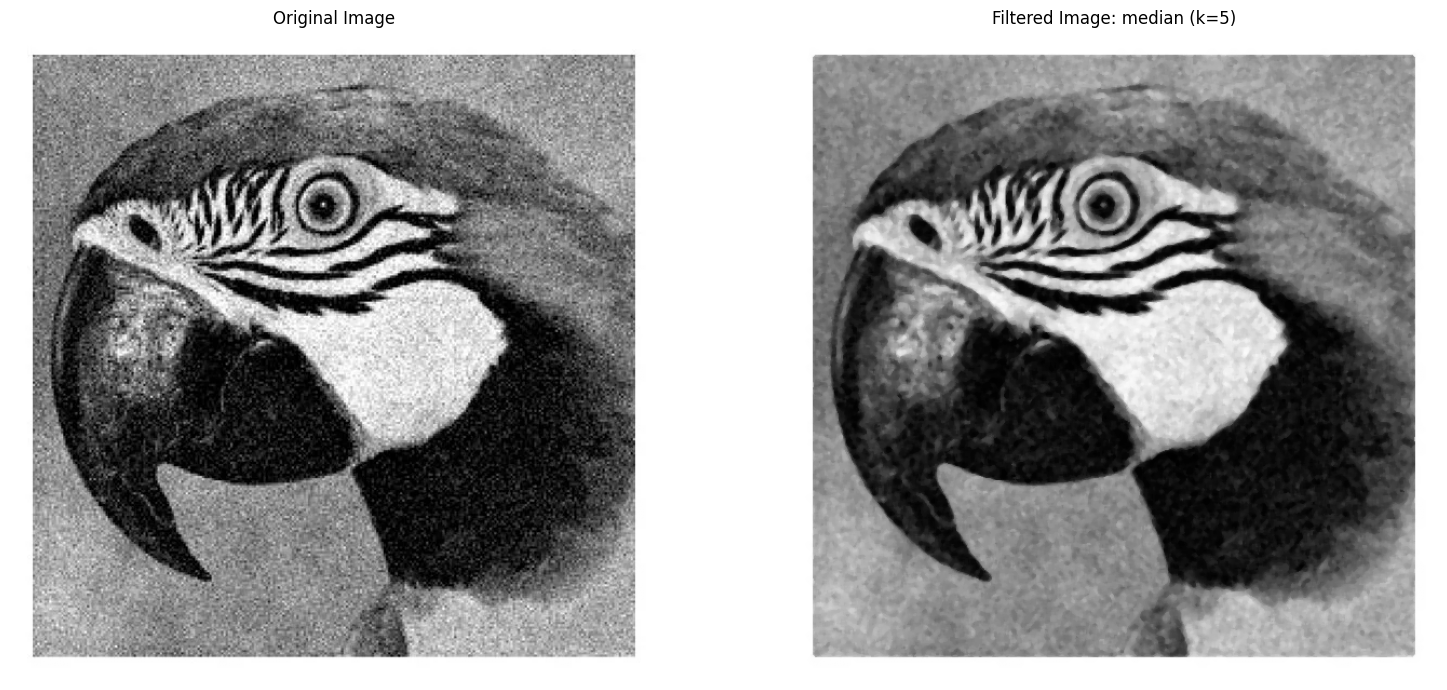

Saved processed image to: C:\Users\vishn\Desktop\Programs\SEM 9\CV Thoery\processed_outputs\median_kernel_5.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(filtered_image, cmap='gray')
axes[1].set_title(f'Filtered Image: {filter_type} (k={kernel_size})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Saved processed image to: {output_path.resolve()}')

## Final Display

This cell presents the side-by-side comparison of the original and filtered images, which is the visual check for how well the selected noise-removal method worked.

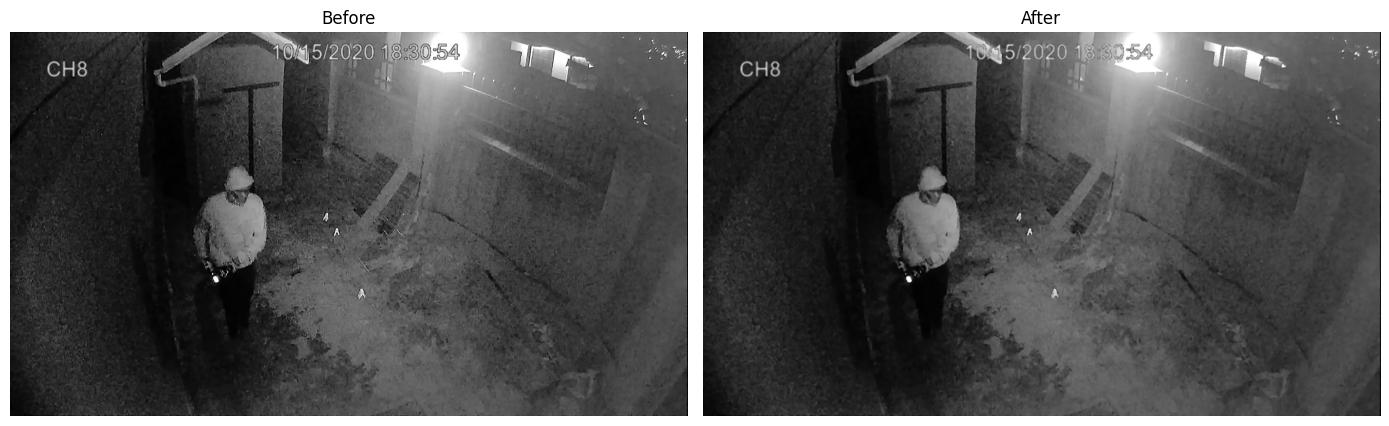

Original image saved to: C:\Users\vishn\Desktop\Programs\SEM 9\CV Thoery\downloaded_document.png
Processed image saved to: C:\Users\vishn\Desktop\Programs\SEM 9\CV Thoery\downloaded_document_after.png


In [13]:
from pathlib import Path
import requests
import cv2
import matplotlib.pyplot as plt

# Web request method for a sample OCR/document image
document_url = 'https://i.sstatic.net/uQUco.jpg'
downloaded_document_path = Path('downloaded_document.png')
processed_document_path = Path('downloaded_document_after.png')

response = requests.get(document_url, timeout=30)
response.raise_for_status()
downloaded_document_path.write_bytes(response.content)

document_image = cv2.imread(str(downloaded_document_path), cv2.IMREAD_GRAYSCALE)
if document_image is None:
    raise ValueError('Failed to load the downloaded document image.')

# After: simple noise removal using a median filter
filtered_document_image = cv2.medianBlur(document_image, 5)
cv2.imwrite(str(processed_document_path), filtered_document_image)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(document_image, cmap='gray')
axes[0].set_title('Before')
axes[0].axis('off')

axes[1].imshow(filtered_document_image, cmap='gray')
axes[1].set_title('After')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Original image saved to: {downloaded_document_path.resolve()}')
print(f'Processed image saved to: {processed_document_path.resolve()}')